# PPG Heart Rate Estimation with S4

Train S4 model on PPG dataset for continuous heart rate estimation.

This notebook follows a standard regression workflow:
- **Task**: Predict heart rate (bpm) from PPG windows
- **Model**: S4-based sequence model
- **Training**: MSE loss with MAE tracking
- **Evaluation**: Test set performance (MAE, RMSE)


In [1]:
from typing import Dict, Any
from pathlib import Path
import torch

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "ppg" / "data")

## Task Definition

Import shared PPGTask from `src.tasks.ppg_task` to avoid code duplication.

In [2]:
from src.notebooks.ppg.ppg_task import PPGTask

## Block Configuration Helper

Using unified block factory for consistent S4 configuration across all experiments.

In [4]:
from src.utils.block_factory import make_s4_block_cfg_ctor

## Configuration

**IMPORTANT**: Update `TRAIN_SUBJECTS`, `VAL_SUBJECT`, and `TEST_SUBJECT` to match your actual dataset subject IDs.

Place your PPG data in: `src/datasets/ppg/data/`

Expected structure:
```
data/
  S1/
    S1.pkl
  S2/
    S2.pkl
  ...
```

Each pickle file should contain:
- `signal['wrist']['BVP']`: PPG signal
- `label`: HR labels (bpm)


In [5]:
TRAIN_SUBJECTS = ("S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8")
VAL_SUBJECT = "S9"
TEST_SUBJECT = "S10"

args: Dict[str, Any] = {
    # Data
    "data_root": data_root,
    "batch": 32,  # Reduced for MPS memory
    "data_loader_kwargs": {
        "num_workers": 0,
        "pin_memory": False,
        "persistent_workers": False,
        # PPGDaliaConfig parameters
        "subjects_train": TRAIN_SUBJECTS,
        "subject_val": VAL_SUBJECT,
        "subject_test": TEST_SUBJECT,
        "fs_in": 64.0,        # Input sampling rate (Hz)
        "fs": 100.0,          # Target sampling rate (Hz)
        "win_sec": 8,         # Window length (seconds)
        "stride_sec": 2,      # Stride (seconds)
        "do_bandpass": True,
        "low_hz": 0.5,
        "high_hz": 8.0,
    },

    # Training
    "epochs": 100,
    "lr": 5e-4,
    "wd": 1e-4,
    "amp": False,  # Disable AMP for MPS stability
    "save_dir": "./runs/ppg_s4_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.01,  # MAE improvement threshold

    # Model (reduced for MPS memory)
    "d_model": 128,      # Reduced from 256
    "depth": 4,          # Reduced from 6
    "dropout": 0.2,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # S4-specific hyperparameters
    "d_state": 64,
    "mode": "s4d",
}

args["block_cfg_ctor"] = make_s4_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
    d_state=args["d_state"],
    mode=args["mode"],
)

# Device selection
import os

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    # Set MPS memory management BEFORE any operations
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
    torch.mps.set_per_process_memory_fraction(0.9)
    print("Using MPS (Apple Silicon) with reduced memory")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

print(f"\nData root: {args['data_root']}")
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Val subject: {VAL_SUBJECT}")
print(f"Test subject: {TEST_SUBJECT}")
print(f"\nS4 Configuration:")
print(f"   d_state: {args['d_state']}")
print(f"   mode: {args['mode']}")
print(f"   bidirectional: {args['bidirectional']}")

Using MPS (Apple Silicon) with reduced memory

Data root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/ppg/data
Train subjects: ('S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8')
Val subject: S9
Test subject: S10

S4 Configuration:
   d_state: 64
   mode: s4d
   bidirectional: False


## Training

In [ ]:
from src.train_utils.trainer import Trainer

# Define the task
task = PPGTask()

# Initialize trainer
trainer = Trainer(args=args, task=task)

# Train
best_metric, best_path = trainer.fit()

history = trainer.history

print(f"\n✅ Training complete! Best validation {trainer.early_key}: {best_metric:.4f}")
print(f"💾 Best model saved to: {best_path}")

## Test Evaluation

Using unified evaluation utilities for consistent regression evaluation.

Evaluating best model on the test set...
✅ Loaded checkpoint from epoch 20
📈 Val MSE: 119.114342, Val MAE: 7.436470


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


Testing:   0%|          | 0/167 [00:00<?, ?it/s]


TEST SET RESULTS:
MSE:  85.973328
MAE:  4.814316
RMSE: 9.272180
✅ Test results saved to: runs/ppg_s4_task/test_results.json


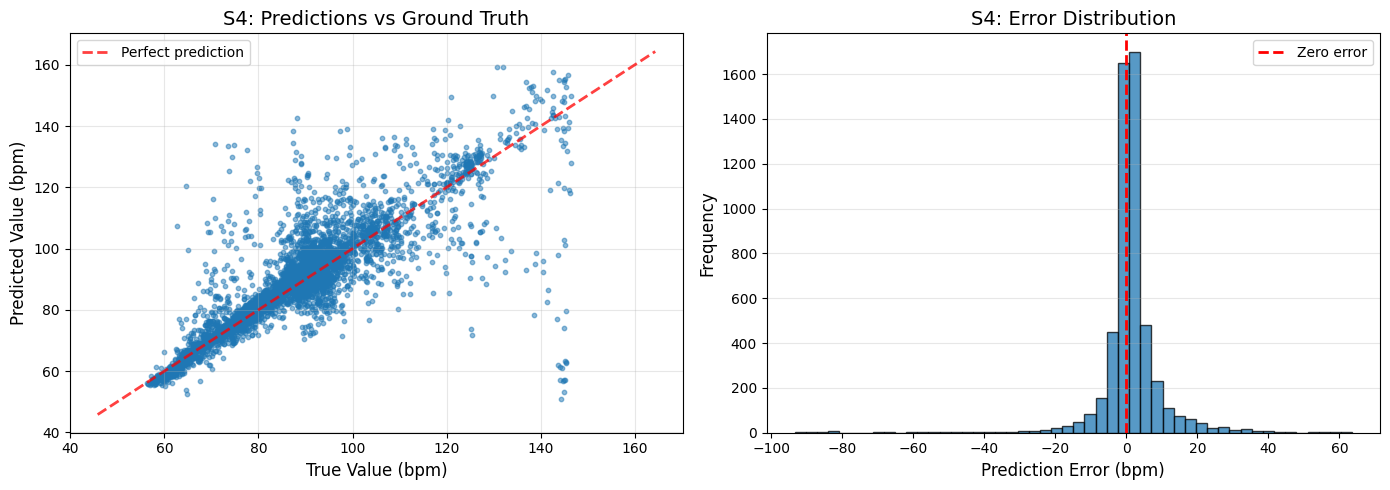


Error Statistics:
  Mean Error: 1.3456 bpm (bias)
  Std Error:  9.1740 bpm
  95% of predictions within: ±17.98 bpm


In [6]:
from src.eval.eval_utils import evaluate_regression_model as evaluate_best_model
from src.utils.visualization import plot_regression_predictions as prediction_visualization

preds, targets = evaluate_best_model(
    args=args,
    task=PPGTask(),
    best_model_path=args["save_dir"] + "/best.pt"
)

prediction_visualization(preds, targets, model_name="S4", unit="bpm")

In [7]:
from src.utils.checkpoint import load_trainer_from_checkpoint
from src.utils.common import print_model_details

trainer = load_trainer_from_checkpoint(
        checkpoint_path=args["save_dir"] + "/best.pt",
        args=args,
        task=PPGTask(),
    )

print_model_details(model=trainer.model)

Loaded checkpoint from epoch 20
Val metrics: {'loss': 119.11434209371856, 'time_s': 23.24868141600018, 'mse': 119.11434209371856, 'mae': 7.436470167754492}

                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: S4CoreAdapter
Number of Blocks: 4

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:                631,297
Trainable parameters:            631,297
Non-trainable parameters:              0
Model size (MB):                    2.41

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
------------------------------

## Changes in datasets length


🔄 Training with fraction: 0.75
   Applying data fraction: 75.0%
   Original train size: 33617
   Original val size: 4277
   Reduced train size: 25212
   Reduced val size: 4277
   Test size: 5321 (unchanged)


💾 saved best model to ./runs/ppg_s4_task_frac_75/best.pt
✅ new best mse 8061.9536
Epoch 000/100 | train 9012.7263/9012.7263 | val 8061.9536/8061.9536 | t 247.1s/12.1s | lr 5.00e-07


💾 saved best model to ./runs/ppg_s4_task_frac_75/best.pt
✅ new best mse 5295.3668
Epoch 001/100 | train 7290.3211/7290.3211 | val 5295.3668/5295.3668 | t 247.2s/12.1s | lr 1.00e-04


💾 saved best model to ./runs/ppg_s4_task_frac_75/best.pt
✅ new best mse 1679.1608
Epoch 002/100 | train 4090.3775/4090.3775 | val 1679.1608/1679.1608 | t 247.0s/12.7s | lr 2.00e-04


💾 saved best model to ./runs/ppg_s4_task_frac_75/best.pt
✅ new best mse 246.9036
Epoch 003/100 | train 888.6025/888.6025 | val 246.9036/246.9036 | t 282.3s/13.1s | lr 3.00e-04


...

Epoch 023/100 | train 43.8147/43.8147 | val 204.1098/204.1098 | t 254.0s/13.1s | lr 4.57e-04


Epoch 024/100 | train 41.1571/41.1571 | val 166.2643/166.2643 | t 271.6s/14.2s | lr 4.52e-04


Epoch 025/100 | train 38.9505/38.9505 | val 144.6909/144.6909 | t 272.0s/14.1s | lr 4.47e-04


Epoch 026/100 | train 37.9141/37.9141 | val 173.4851/173.4851 | t 284.1s/14.3s | lr 4.42e-04


⏹ Early stopping (patience=5, best=132.9305).
📊 Training history saved to ./runs/ppg_s4_task_frac_75/history.json

✅ Training complete for fraction 0.75! Best validation mse: 132.9305
💾 Best model saved to: ./runs/ppg_s4_task_frac_75/best.pt


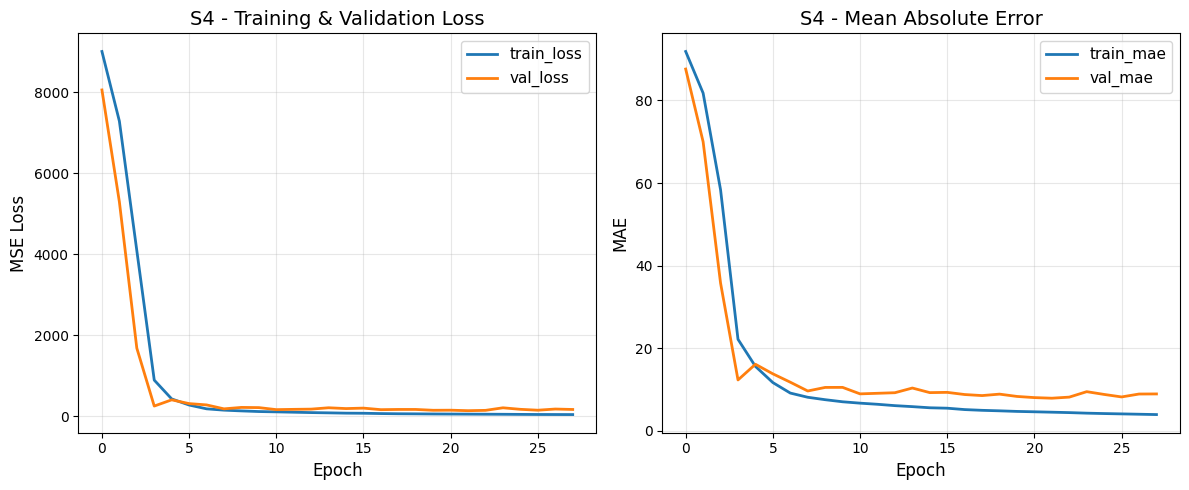

Evaluating best model on the test set...
✅ Loaded checkpoint from epoch 21
📈 Val MSE: 132.930533, Val MAE: 7.929894


Testing:   0%|          | 0/167 [00:00<?, ?it/s]


TEST SET RESULTS:
MSE:  80.465149
MAE:  6.037535
RMSE: 8.970237
✅ Test results saved to: runs/ppg_s4_task_frac_75/test_results.json


In [9]:
from src.utils.visualization import plot_regression_history as plot_train_history
from src.eval.eval_utils import evaluate_regression_model as evaluate_best_model
from src.train_utils.trainer import Trainer

for frac in [0.1, 0.25, 0.5]:

    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/ppg_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=PPGTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_train_history(history, model_name="S4")

    preds, targets = evaluate_best_model(
        args=args,
        task=PPGTask(),
        best_model_path=best_path
    )